In [79]:
from datetime import datetime, timedelta
import uo_pyfetch
import calendar
from datetime import datetime, timezone
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
import requests
import csv
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML
from pyproj import Transformer
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
import matplotlib.pyplot as plt


In [80]:
bbox = [-1.652756, 54.973377, -1.620483, 54.983721]

In [81]:
variables = uo_pyfetch.get_variables()
print("Available variables:")
for v in variables["Variables"][:1000]:
    print(f" - {v['Name']} ({v.get('Units', 'no units')})")

Available variables:
 - allpollu (%)
 - Ammonia (?)
 - Average Speed (KmPH)
 - Battery (V)
 - Brood (Celsius)
 - Bus Count (Vehicles)
 - Bus Count East (Vehicles)
 - Bus Count West (Vehicles)
 - Car Count (Vehicles)
 - Cars (Cars)
 - CO (ugm -3)
 - CO2 (ppm)
 - CO2 High Range (ppm)
 - CO2 Low Range (ppm)
 - Congestion (%)
 - Cycle Count (Vehicles)
 - Daily Accumulation Rainfall (mm)
 - Depth (m)
 - Dew Point (Celsius)
 - Dissolved Oxygen (mg/l)
 - Dissolved Oxygen Percentage (%)
 - Dust (?)
 - East-West Horizontal Displacement (m)
 - Filter (%)
 - Fluorescent Dissolved Organic Matter (QSU)
 - Hive Activity (-)
 - Humidity (%)
 - Internal Humidity (%)
 - Internal Temperature (Celsius)
 - Journey Time (seconds)
 - Luminosity (Lux)
 - Max Sound (db)
 - Max Temperature  (Celsius)
 - Max Wind Speed (m/s)
 - Mean Fanning (-)
 - Mean Flight Noise (-)
 - Moisture (%)
 - Motorcycle Count (Vehicles)
 - NH4+N (mg/l)
 - NO (ugm -3)
 - NO2 (ugm -3)
 - NO2 Concentration (ugm -3)
 - NO3-N (mg/l)
 - N

In [82]:
themes = uo_pyfetch.get_themes()
print("\nAvailable themes:")
for t in themes["Themes"]:
    print(f" - {t['Name']}")


Available themes:
 - Sewage
 - Sensor Metrics
 - Electrical
 - Seismic
 - Water Quality
 - Traffic
 - Air Quality
 - Water Level
 - Bee Hive
 - People
 - Building
 - Environment
 - Weather
 - Noise
 - Vehicles


In [83]:
print("\nFetching sensors in bbox...")
sensors_df = uo_pyfetch.get_sensors() #bondary box


Fetching sensors in bbox...


In [84]:
#amount of sensors
print(sensors_df.drop_duplicates().count())

Sensor_Name                      1000
Location_WKT                     1000
Sensor_Centroid_Longitude        1000
Ground_Height_Above_Sea_Level    1000
Sensor_Centroid_Latitude         1000
Sensor_Height_Above_Ground       1000
Broker_Name                      1000
Raw_ID                           1000
dtype: int64


In [85]:
display(HTML(sensors_df.head(5).to_html()))

,Sensor_Name,Location_WKT,Sensor_Centroid_Longitude,Ground_Height_Above_Sea_Level,Sensor_Centroid_Latitude,Sensor_Height_Above_Ground,Broker_Name,Raw_ID
0,PER_WUNDERGROUND_ICRAWCRO3,POINT(-1.778519 54.965347),-1.778519,98.860001,54.965347,2.0,Wunderground API,1
1,PER_WUNDERGROUND_ITYNEAND12,POINT(-1.476 55.037),-1.476000,46.709999,55.037000,2.0,Wunderground API,2
2,PER_NEWCASTLE_GREATNORTH_PARK_PARK_&_RIDE,POINT(-1.6459751 55.0335563),-1.645975,66.699997,55.033556,2.0,Newcastle Council RSS feed,3
3,PER_WUNDERGROUND_ITYNEWHI2,POINT(-1.489034 55.042614),-1.489034,47.230000,55.042614,2.0,Wunderground API,4
4,PER_WUNDERGROUND_ISEATOND2,POINT(-1.529 55.076),-1.529000,36.590000,55.076000,2.0,Wunderground API,7


In [86]:
#variables for congestion
variables = [   
"Plates Out",
"Plates In",
"Plates Matching",
"Journey Time",
#"Temperature",
#"Humidity", 
#"Pressure"
]


In [87]:
n = 100
print("\nFetching sensor data (last n days)...")
sensor_data_df = uo_pyfetch.get_sensor_data(
    last_n_hours=n*24,
    variables=variables,
    bbox=bbox,
    limit=10000000
)


Fetching sensor data (last n days)...


In [88]:
display(HTML(sensor_data_df.head(50).to_html()))

,Sensor_Name,Variable,Value,Timestamp,Flagged,Location_WKT,Sensor_Centroid_Longitude,Ground_Height_Above_Sea_Level,Sensor_Centroid_Latitude,Sensor_Height_Above_Ground,Broker_Name,Raw_ID
0,PER_NE_CAJT_NCA189_BR3_SJB2,Journey Time,99.0,2025-08-07 18:35:00,False,"LINESTRING(-1.63616906955424 54.9817218898528,-1.62158717134441 54.973787503231)",-1.628878,79.949997,54.977755,2.0,NE Travel Data API,73162
1,PER_NE_CAJT_NCA189_BR3_SJB2,Plates In,0.0,2025-08-07 18:35:00,False,"LINESTRING(-1.63616906955424 54.9817218898528,-1.62158717134441 54.973787503231)",-1.628878,79.949997,54.977755,2.0,NE Travel Data API,73162
2,PER_NE_CAJT_NCA189_BR3_SJB2,Plates Out,27.0,2025-08-07 18:35:00,False,"LINESTRING(-1.63616906955424 54.9817218898528,-1.62158717134441 54.973787503231)",-1.628878,79.949997,54.977755,2.0,NE Travel Data API,73162
3,PER_NE_CAJT_NCA189_BR3_SJB2,Plates Matching,1.0,2025-08-07 18:35:00,False,"LINESTRING(-1.63616906955424 54.9817218898528,-1.62158717134441 54.973787503231)",-1.628878,79.949997,54.977755,2.0,NE Travel Data API,73162
4,PER_NE_CAJT_NCA189_SJB2_BR3,Journey Time,96.0,2025-08-07 18:35:00,False,"LINESTRING(-1.62151252520077 54.9734188344729,-1.63570463447405 54.9812442299792)",-1.628609,75.330002,54.977332,2.0,NE Travel Data API,73173
5,PER_NE_CAJT_NCA189_SJB2_BR3,Plates In,25.0,2025-08-07 18:35:00,False,"LINESTRING(-1.62151252520077 54.9734188344729,-1.63570463447405 54.9812442299792)",-1.628609,75.330002,54.977332,2.0,NE Travel Data API,73173
6,PER_NE_CAJT_NCA189_SJB2_BR3,Plates Out,0.0,2025-08-07 18:35:00,False,"LINESTRING(-1.62151252520077 54.9734188344729,-1.63570463447405 54.9812442299792)",-1.628609,75.330002,54.977332,2.0,NE Travel Data API,73173
7,PER_NE_CAJT_NCA189_SJB2_BR3,Plates Matching,0.0,2025-08-07 18:35:00,False,"LINESTRING(-1.62151252520077 54.9734188344729,-1.63570463447405 54.9812442299792)",-1.628609,75.330002,54.977332,2.0,NE Travel Data API,73173
8,PER_NE_CAJT_NCA189_SJB2_BR3,Journey Time,187.0,2025-08-07 18:38:00,False,"LINESTRING(-1.62151252520077 54.9734188344729,-1.63570463447405 54.9812442299792)",-1.628609,75.330002,54.977332,2.0,NE Travel Data API,73173
9,PER_NE_CAJT_NCA189_SJB2_BR3,Plates In,26.0,2025-08-07 18:38:00,False,"LINESTRING(-1.62151252520077 54.9734188344729,-1.63570463447405 54.9812442299792)",-1.628609,75.330002,54.977332,2.0,NE Travel Data API,73173


In [89]:

print(sensor_data_df["Variable"].drop_duplicates())

0       Journey Time
1          Plates In
2         Plates Out
3    Plates Matching
Name: Variable, dtype: object


In [90]:
print("Data shape:", sensor_data_df.shape)
print("Columns:", sensor_data_df.columns)
print("Missing values per column:\n", sensor_data_df.isnull().sum())
print(sensor_data_df.describe())

Data shape: (204496, 12)
Columns: Index(['Sensor_Name', 'Variable', 'Value', 'Timestamp', 'Flagged',
       'Location_WKT', 'Sensor_Centroid_Longitude',
       'Ground_Height_Above_Sea_Level', 'Sensor_Centroid_Latitude',
       'Sensor_Height_Above_Ground', 'Broker_Name', 'Raw_ID'],
      dtype='object')
Missing values per column:
 Sensor_Name                      0
Variable                         0
Value                            0
Timestamp                        0
Flagged                          0
Location_WKT                     0
Sensor_Centroid_Longitude        0
Ground_Height_Above_Sea_Level    0
Sensor_Centroid_Latitude         0
Sensor_Height_Above_Ground       0
Broker_Name                      0
Raw_ID                           0
dtype: int64
               Value  Sensor_Centroid_Longitude  \
count  204496.000000              204496.000000   
mean       56.610618                  -1.628743   
std        69.827737                   0.000135   
min         0.000000         

In [91]:
def pivot_variables(df):
    pivoted = df.pivot_table(
        index=["Timestamp", "Sensor_Name"],
        columns="Variable",
        values="Value",
        aggfunc="mean"     # in case multiple values per timestamp
    ).reset_index()

    return pivoted
    
pivoted_sensor_data_df = pivot_variables(sensor_data_df)
display(HTML(pivoted_sensor_data_df.head(50).to_html()))


Variable,Timestamp,Sensor_Name,Journey Time,Plates In,Plates Matching,Plates Out
0,2025-08-07 18:35:00,PER_NE_CAJT_NCA189_BR3_SJB2,99.0,0.0,1.0,27.0
1,2025-08-07 18:35:00,PER_NE_CAJT_NCA189_SJB2_BR3,96.0,25.0,0.0,0.0
2,2025-08-07 18:38:00,PER_NE_CAJT_NCA189_BR3_SJB2,161.0,128.0,10.0,18.0
3,2025-08-07 18:38:00,PER_NE_CAJT_NCA189_SJB2_BR3,187.0,26.0,16.0,82.0
4,2025-08-07 18:42:00,PER_NE_CAJT_NCA189_BR3_SJB2,172.0,67.0,4.0,16.0
5,2025-08-07 18:42:00,PER_NE_CAJT_NCA189_SJB2_BR3,176.0,22.0,14.0,62.0
6,2025-08-07 18:54:00,PER_NE_CAJT_NCA189_BR3_SJB2,178.0,48.0,13.0,25.0
7,2025-08-07 18:54:00,PER_NE_CAJT_NCA189_SJB2_BR3,156.0,33.0,10.0,57.0
8,2025-08-07 18:58:00,PER_NE_CAJT_NCA189_BR3_SJB2,175.0,59.0,6.0,22.0
9,2025-08-07 18:58:00,PER_NE_CAJT_NCA189_SJB2_BR3,149.0,34.0,14.0,54.0


In [92]:
#removing outliers
def remove_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return df[(df[column] >= lower) & (df[column] <= upper)]
    
removeoutlier_sensor_data_df = remove_outliers_iqr(pivoted_sensor_data_df, "Journey Time")
removeoutlier_sensor_data_df = remove_outliers_iqr(removeoutlier_sensor_data_df, "Plates In")
removeoutlier_sensor_data_df = remove_outliers_iqr(removeoutlier_sensor_data_df, "Plates Matching")
removeoutlier_sensor_data_df = remove_outliers_iqr(removeoutlier_sensor_data_df, "Plates Out")
removeoutlier_sensor_data_df = removeoutlier_sensor_data_df[removeoutlier_sensor_data_df["Journey Time"] > 100]




Basic Info:

<class 'pandas.core.frame.DataFrame'>
Int64Index: 36549 entries, 3 to 51123
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Timestamp        36549 non-null  object 
 1   Sensor_Name      36549 non-null  object 
 2   Journey Time     36549 non-null  float64
 3   Plates In        36549 non-null  float64
 4   Plates Matching  36549 non-null  float64
 5   Plates Out       36549 non-null  float64
dtypes: float64(4), object(2)
memory usage: 2.0+ MB
None

Missing Values:

Variable
Timestamp          0
Sensor_Name        0
Journey Time       0
Plates In          0
Plates Matching    0
Plates Out         0
dtype: int64

Statistical Summary:

Variable  Journey Time     Plates In  Plates Matching    Plates Out
count     36549.000000  36549.000000     36549.000000  36549.000000
mean        164.190210     37.788722         9.547129     33.375332
std          33.839905     25.175734         5.250182     20

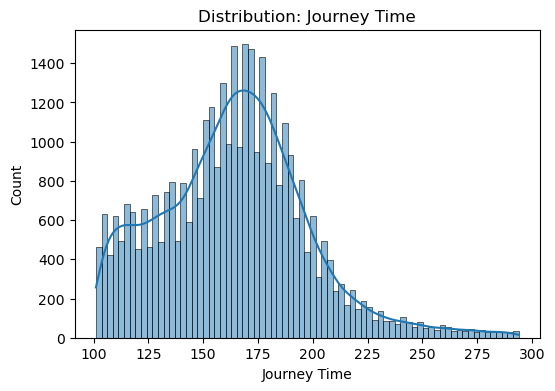

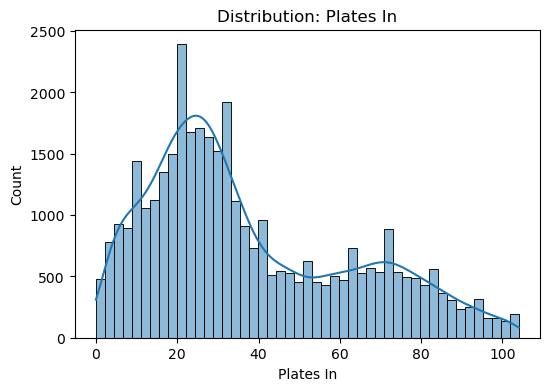

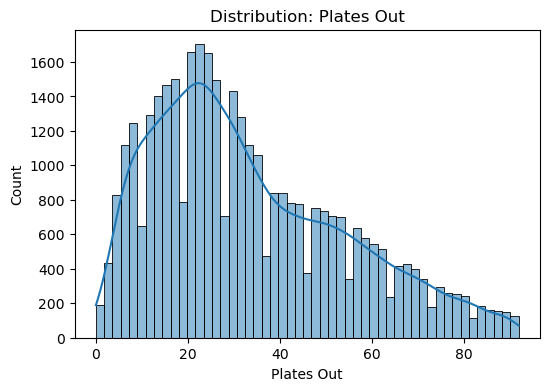

In [93]:

def explore_data(df):
    print("\nBasic Info:\n")
    print(df.info())

    print("\nMissing Values:\n")
    print(df.isna().sum().sort_values(ascending=False))

    print("\nStatistical Summary:\n")
    print(df.describe())

    # Plot distribution of key variables
    to_plot = ["Journey Time", "Plates In", "Plates Out", "PM2.5", "NO2", "Temperature"]
    for col in to_plot:
        if col in df.columns:
            plt.figure(figsize=(6,4))
            sns.histplot(df[col], kde=True)
            plt.title(f"Distribution: {col}")
            plt.show()


explore_data(removeoutlier_sensor_data_df)



In [94]:
# 4. FEATURE ENGINEERING
def add_time_features(df):
    df["Timestamp"] = pd.to_datetime(df["Timestamp"])
    df["hour"] = df["Timestamp"].dt.hour
    df["day"] = df["Timestamp"].dt.day
    df["weekday"] = df["Timestamp"].dt.weekday
    df["month"] = df["Timestamp"].dt.month
    df["is_weekend"] = df["weekday"].isin([5, 6]).astype(int)
    return df

def add_lag_features(df, cols, lags=[1, 3, 6]):
    for col in cols:
        for lag in lags:
            df[f"{col}_lag_{lag}"] = df[col].shift(lag)
    return df

def add_rolling_features(df, cols, windows=[3, 6]):
    for col in cols:
        for w in windows:
            df[f"{col}_roll_{w}"] = df[col].rolling(w).mean()
    return df

time_features_df = add_time_features(removeoutlier_sensor_data_df)
#lag_features_df = add_lag_features(time_features_df, ["Journey Time", "Plates In", "Plates Matching", "Plates Out"])
#rolling_features = add_rolling_features(lag_features_df, ["Journey Time", "Plates In", "Plates Matching", "Plates Out"])

In [107]:

dropna = time_features_df.dropna()

display(HTML(dropna.head(10).to_html()))


Variable,Timestamp,Sensor_Name,Journey Time,Plates In,Plates Matching,Plates Out,hour,day,weekday,month,is_weekend
3,2025-08-07 18:38:00,PER_NE_CAJT_NCA189_SJB2_BR3,187.0,26.0,16.0,82.0,18,7,3,8,0
4,2025-08-07 18:42:00,PER_NE_CAJT_NCA189_BR3_SJB2,172.0,67.0,4.0,16.0,18,7,3,8,0
5,2025-08-07 18:42:00,PER_NE_CAJT_NCA189_SJB2_BR3,176.0,22.0,14.0,62.0,18,7,3,8,0
6,2025-08-07 18:54:00,PER_NE_CAJT_NCA189_BR3_SJB2,178.0,48.0,13.0,25.0,18,7,3,8,0
7,2025-08-07 18:54:00,PER_NE_CAJT_NCA189_SJB2_BR3,156.0,33.0,10.0,57.0,18,7,3,8,0
8,2025-08-07 18:58:00,PER_NE_CAJT_NCA189_BR3_SJB2,175.0,59.0,6.0,22.0,18,7,3,8,0
9,2025-08-07 18:58:00,PER_NE_CAJT_NCA189_SJB2_BR3,149.0,34.0,14.0,54.0,18,7,3,8,0
10,2025-08-07 19:02:00,PER_NE_CAJT_NCA189_BR3_SJB2,151.0,62.0,11.0,27.0,19,7,3,8,0
11,2025-08-07 19:02:00,PER_NE_CAJT_NCA189_SJB2_BR3,157.0,33.0,22.0,73.0,19,7,3,8,0
12,2025-08-07 19:06:00,PER_NE_CAJT_NCA189_BR3_SJB2,186.0,41.0,5.0,13.0,19,7,3,8,0


In [108]:
# =========================================================
# 5. GENERATE CONGESTION LABEL
# =========================================================

def generate_congestion(df):
    # Required columns
    required = {"Journey Time", "Plates In", "Plates Out", "Plates Matching"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"Missing required variables: {missing}")

    # Traffic volume
    df["traffic_volume"] = df["Plates In"] + df["Plates Out"] + df["Plates Matching"]

    # --- Journey Time Normalisation ---
    JT_free = df["Journey Time"].quantile(0.10)    # free-flow threshold
    JT_worst = df["Journey Time"].quantile(0.95)   # worst-case threshold
    df["jt_norm"] = (df["Journey Time"] - JT_free) / (JT_worst - JT_free)
    df["jt_norm"] = df["jt_norm"].clip(0, 1)

    # --- Volume Normalisation ---
    VOL_high = df["traffic_volume"].quantile(0.90)
    df["vol_norm"] = df["traffic_volume"] / VOL_high
    df["vol_norm"] = df["vol_norm"].clip(0, 1)

    # --- Hybrid Congestion Metric ---
    df["Congestion"] = 100 * (
        0.6 * df["jt_norm"] + 
        0.4 * df["vol_norm"]
    )

    return df



target_variable_df = generate_congestion(dropna)


In [110]:
display(HTML(target_variable_df.head(10).sort_values("Congestion").to_html()))


Variable,Timestamp,Sensor_Name,Journey Time,Plates In,Plates Matching,Plates Out,hour,day,weekday,month,is_weekend,traffic_volume,jt_norm,vol_norm,Congestion
9,2025-08-07 18:58:00,PER_NE_CAJT_NCA189_SJB2_BR3,149.0,34.0,14.0,54.0,18,7,3,8,0,102.0,0.300971,0.809524,50.439205
10,2025-08-07 19:02:00,PER_NE_CAJT_NCA189_BR3_SJB2,151.0,62.0,11.0,27.0,19,7,3,8,0,100.0,0.320388,0.793651,50.969333
7,2025-08-07 18:54:00,PER_NE_CAJT_NCA189_SJB2_BR3,156.0,33.0,10.0,57.0,18,7,3,8,0,100.0,0.368932,0.793651,53.881954
12,2025-08-07 19:06:00,PER_NE_CAJT_NCA189_BR3_SJB2,186.0,41.0,5.0,13.0,19,7,3,8,0,59.0,0.660194,0.468254,58.341809
4,2025-08-07 18:42:00,PER_NE_CAJT_NCA189_BR3_SJB2,172.0,67.0,4.0,16.0,18,7,3,8,0,87.0,0.524272,0.690476,59.075358
8,2025-08-07 18:58:00,PER_NE_CAJT_NCA189_BR3_SJB2,175.0,59.0,6.0,22.0,18,7,3,8,0,87.0,0.553398,0.690476,60.822931
6,2025-08-07 18:54:00,PER_NE_CAJT_NCA189_BR3_SJB2,178.0,48.0,13.0,25.0,18,7,3,8,0,86.0,0.582524,0.682540,62.253044
11,2025-08-07 19:02:00,PER_NE_CAJT_NCA189_SJB2_BR3,157.0,33.0,22.0,73.0,19,7,3,8,0,128.0,0.378641,1.000000,62.718447
5,2025-08-07 18:42:00,PER_NE_CAJT_NCA189_SJB2_BR3,176.0,22.0,14.0,62.0,18,7,3,8,0,98.0,0.563107,0.777778,64.897519
3,2025-08-07 18:38:00,PER_NE_CAJT_NCA189_SJB2_BR3,187.0,26.0,16.0,82.0,18,7,3,8,0,124.0,0.669903,0.984127,79.559254


In [119]:

droped_columns = target_variable_df.drop(
    columns=["Timestamp", "Sensor_Name", "jt_norm", "vol_norm", "traffic_volume"]
)
display(HTML(droped_columns.head(10).sort_values("Congestion").to_html()))



Variable,Journey Time,Plates In,Plates Matching,Plates Out,hour,day,weekday,month,is_weekend,Congestion
9,149.0,34.0,14.0,54.0,18,7,3,8,0,50.439205
10,151.0,62.0,11.0,27.0,19,7,3,8,0,50.969333
7,156.0,33.0,10.0,57.0,18,7,3,8,0,53.881954
12,186.0,41.0,5.0,13.0,19,7,3,8,0,58.341809
4,172.0,67.0,4.0,16.0,18,7,3,8,0,59.075358
8,175.0,59.0,6.0,22.0,18,7,3,8,0,60.822931
6,178.0,48.0,13.0,25.0,18,7,3,8,0,62.253044
11,157.0,33.0,22.0,73.0,19,7,3,8,0,62.718447
5,176.0,22.0,14.0,62.0,18,7,3,8,0,64.897519
3,187.0,26.0,16.0,82.0,18,7,3,8,0,79.559254


In [121]:
# ---------------------------------------------------------
# 2. Final DF
# ---------------------------------------------------------
df = droped_columns

In [126]:
# ---------------------------------------------------------
# 2. SELECT NUMERIC FEATURES ONLY (XGBoost requirement)
# ---------------------------------------------------------

numeric_df = df.select_dtypes(include=[np.number]).copy()

# Remove label from feature set
X = numeric_df.drop(columns=["Congestion"])
y = numeric_df["Congestion"]

display(HTML(numeric_df.head(10).sort_values("Congestion").to_html()))


Variable,Journey Time,Plates In,Plates Matching,Plates Out,hour,day,weekday,month,is_weekend,Congestion
9,149.0,34.0,14.0,54.0,18,7,3,8,0,50.439205
10,151.0,62.0,11.0,27.0,19,7,3,8,0,50.969333
7,156.0,33.0,10.0,57.0,18,7,3,8,0,53.881954
12,186.0,41.0,5.0,13.0,19,7,3,8,0,58.341809
4,172.0,67.0,4.0,16.0,18,7,3,8,0,59.075358
8,175.0,59.0,6.0,22.0,18,7,3,8,0,60.822931
6,178.0,48.0,13.0,25.0,18,7,3,8,0,62.253044
11,157.0,33.0,22.0,73.0,19,7,3,8,0,62.718447
5,176.0,22.0,14.0,62.0,18,7,3,8,0,64.897519
3,187.0,26.0,16.0,82.0,18,7,3,8,0,79.559254


In [127]:

# ---------------------------------------------------------
# 3. TRAIN/TEST SPLIT
# ---------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    shuffle=False     # IMPORTANT for time-series!!
)

In [128]:

# ---------------------------------------------------------
# 4. XGBoost Model
# ---------------------------------------------------------

model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    tree_method="hist",      # Faster training
    random_state=42
)
model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=None, num_parallel_tree=None, ...)

In [129]:
# ---------------------------------------------------------
# 5. Evaluation
# ---------------------------------------------------------

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred, squared=False)
r2 = r2_score(y_test, y_pred)

print("XGBoost Congestion Model Performance:")
print(f"MAE : {mae:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"R²  : {r2:.3f}")

XGBoost Congestion Model Performance:
MAE : 0.301
RMSE: 0.404
R²  : 1.000


In [118]:


for actual, pred in zip(y_test, y_pred):
    print(f"Actual: {actual:.2f}  |  Predicted: {pred:.2f}")

Actual: 60.98  |  Predicted: 60.84
Actual: 46.90  |  Predicted: 46.88
Actual: 74.22  |  Predicted: 74.43
Actual: 52.46  |  Predicted: 52.49
Actual: 63.79  |  Predicted: 63.69
Actual: 42.51  |  Predicted: 42.37
Actual: 64.26  |  Predicted: 64.22
Actual: 41.66  |  Predicted: 41.67
Actual: 64.32  |  Predicted: 64.20
Actual: 37.00  |  Predicted: 36.89
Actual: 52.62  |  Predicted: 52.68
Actual: 34.89  |  Predicted: 34.70
Actual: 40.02  |  Predicted: 40.02
Actual: 37.74  |  Predicted: 37.77
Actual: 33.29  |  Predicted: 33.49
Actual: 39.17  |  Predicted: 39.30
Actual: 39.05  |  Predicted: 37.81
Actual: 34.61  |  Predicted: 34.53
Actual: 27.41  |  Predicted: 27.36
Actual: 14.18  |  Predicted: 14.22
Actual: 38.32  |  Predicted: 38.35
Actual: 16.51  |  Predicted: 16.55
Actual: 35.09  |  Predicted: 35.05
Actual: 25.35  |  Predicted: 25.43
Actual: 45.58  |  Predicted: 45.55
Actual: 29.69  |  Predicted: 29.81
Actual: 48.59  |  Predicted: 48.30
Actual: 32.02  |  Predicted: 31.89
Actual: 58.81  |  Pr